In [46]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, balanced_accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

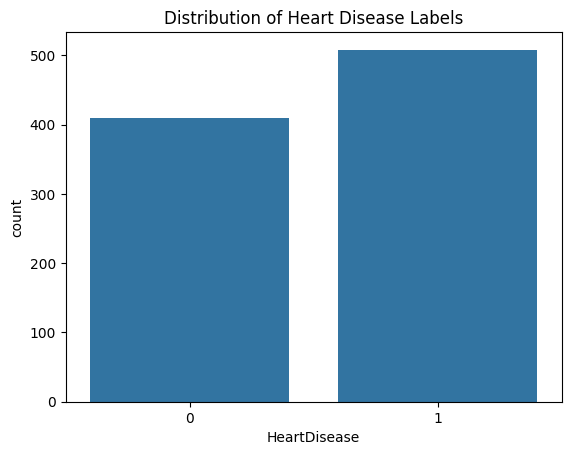

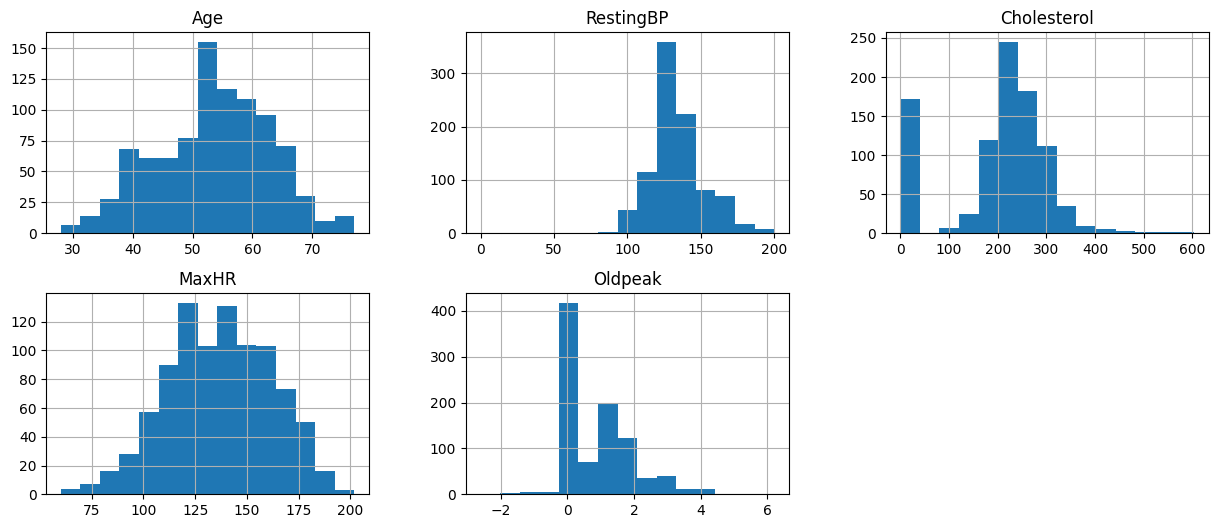

In [47]:
# Load data
df = pd.read_csv('heart.csv')

# 1. Target Label Distribution
sns.countplot(data=df, x='HeartDisease')
plt.title('Distribution of Heart Disease Labels')
plt.show()

# 2. Numerical Distributions
numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
df[numeric_features].hist(bins=15, figsize=(15, 6), layout=(2, 3))
plt.show()

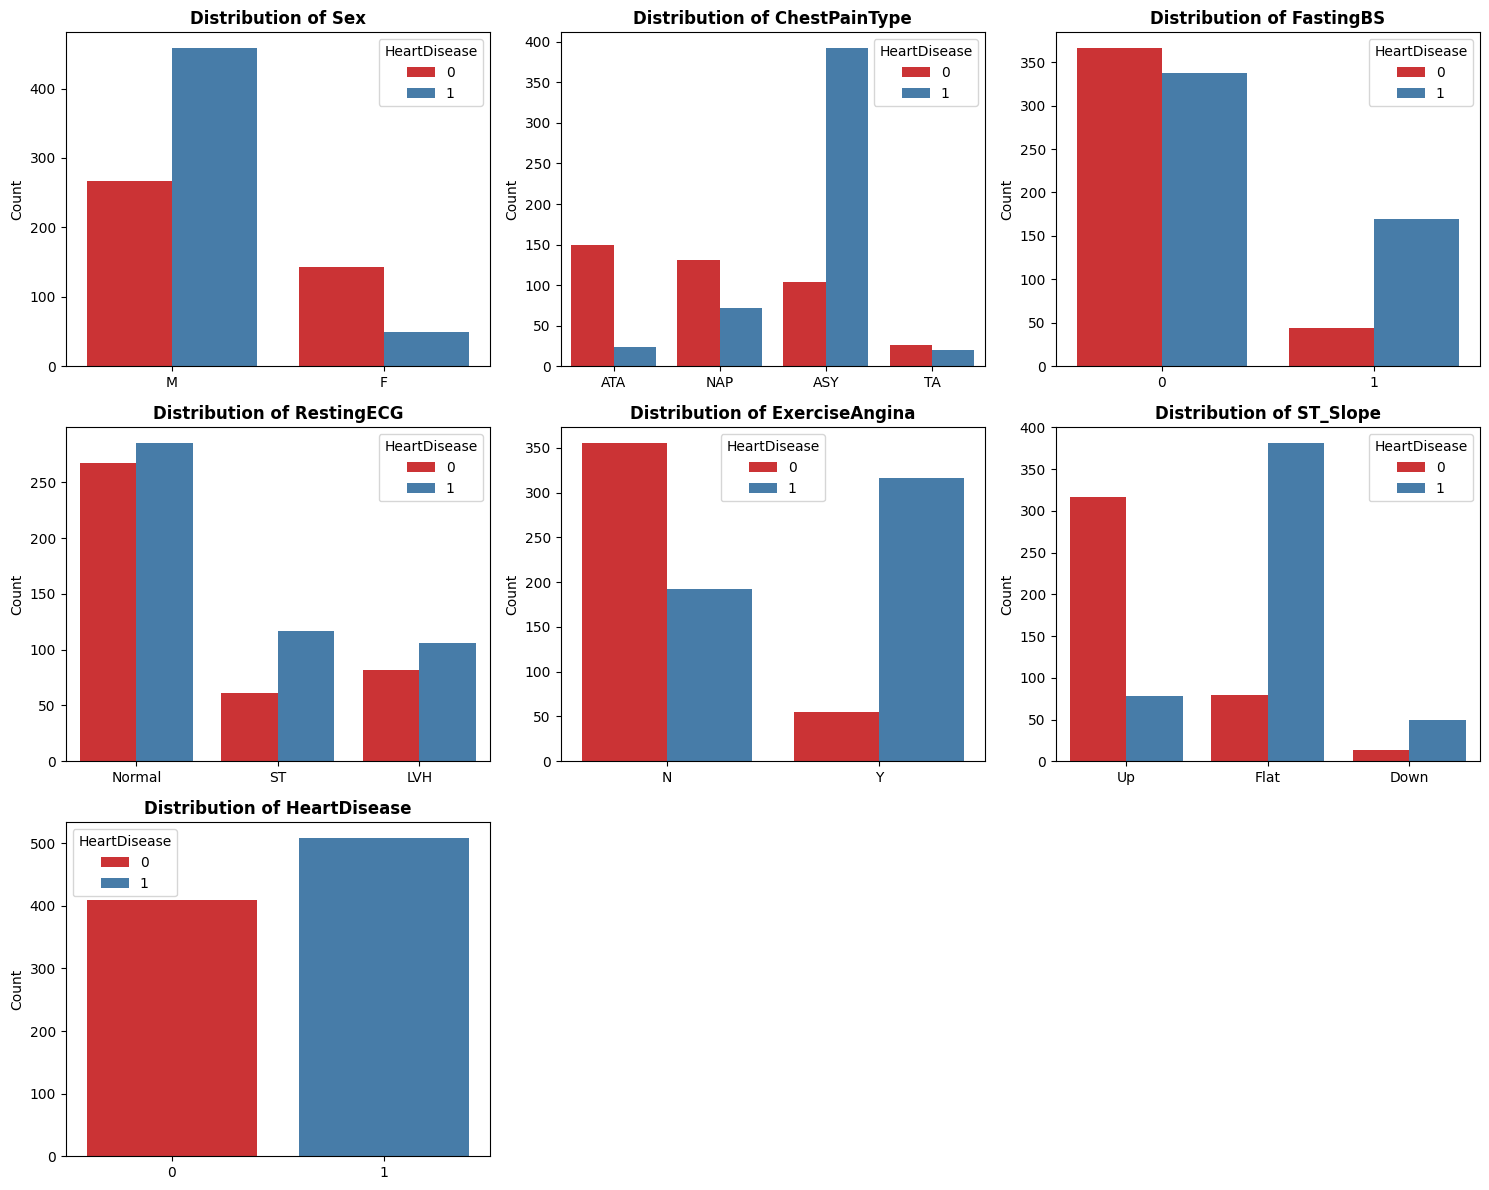

In [48]:
categorical_features = [
    'Sex', 'ChestPainType', 'FastingBS', 
    'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease'
]

# 2. Set up a grid of subplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))

axes = axes.flatten()

# 3. Loop through the features and create a countplot for each
for i, feature in enumerate(categorical_features):
    # Create the plot on the specific subplot axis (ax=axes[i])
    sns.countplot(data=df, x=feature, hue='HeartDisease', ax=axes[i], palette='Set1')
    
    # Add titles and labels for clarity
    axes[i].set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].set_xlabel('') # Hide x-label to keep it clean, the ticks are enough

# 4. Clean up empty subplots
for j in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Zero Cholesterol rows: 172
Zero RestingBP rows: 1


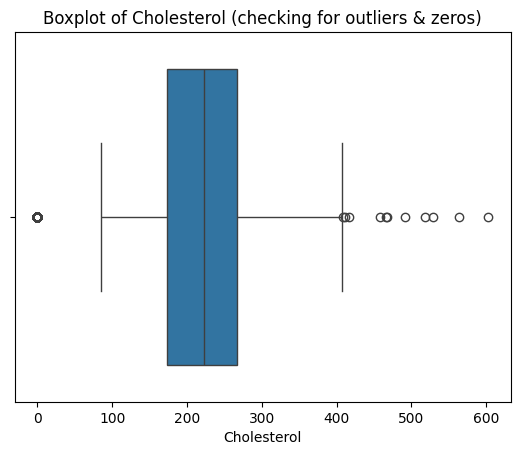

In [49]:
# Check for impossible zero values
print("Zero Cholesterol rows:", (df['Cholesterol'] == 0).sum())
print("Zero RestingBP rows:", (df['RestingBP'] == 0).sum())

# Visualize outliers using a Boxplot
sns.boxplot(x=df['Cholesterol'])
plt.title('Boxplot of Cholesterol (checking for outliers & zeros)')
plt.show()

In [50]:
# 1. Load data and the custom splits
df = pd.read_csv('heart.csv')
splits_df = pd.read_csv('splits_heart.csv')

# 2. Handle the "Hidden" Missing Data
# Biologically, Cholesterol and RestingBP cannot be 0. We must replace 0 with NaN 
cols_with_zeros = ['Cholesterol', 'RestingBP']
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

# 3. Separate Features (X) and Target (y)
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# 4. custom Train/Test Split
train_indices = splits_df[splits_df['split'] == 'train']['row_index']
test_indices = splits_df[splits_df['split'] == 'test']['row_index']

X_train = X.loc[train_indices]
X_test = X.loc[test_indices]
y_train = y.loc[train_indices]
y_test = y.loc[test_indices]

# Define Feature Groups
numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
categorical_features = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

# Create Preprocessing Pipelines

# For numerical features: Impute missing values with the median, then scale.
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# For categorical features: Impute missing values with the mode, then One-Hot Encode.
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine both pipelines using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Execute the Preprocessing
# Fit ONLY on the training data, then transform both train and test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert back to Pandas DataFrames for easier viewing or NAMs ingestion
cat_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

X_train_final = pd.DataFrame(X_train_processed, columns=all_feature_names, index=X_train.index)
X_test_final = pd.DataFrame(X_test_processed, columns=all_feature_names, index=X_test.index)

print("Shape of original X_train:", X_train.shape)
print("Shape of processed X_train:", X_train_final.shape)
print("\nProcessed Training Data Head:")
display(X_train_final.head())

Shape of original X_train: (734, 11)
Shape of processed X_train: (734, 21)

Processed Training Data Head:


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,...,FastingBS_0,FastingBS_1,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.467942,0.394362,0.810563,1.379936,-0.819056,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-0.619958,0.283669,-0.572835,-1.099273,0.601071,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.016030,0.947827,-0.923296,-0.556946,-0.819056,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
5,-1.573940,-0.712567,1.732828,1.302460,-0.819056,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
6,-0.937952,-0.159102,-0.148593,1.302460,-0.819056,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


In [51]:
# --- Q2.1: Fit the Logistic Lasso Regression ---
lasso_model = LogisticRegression(l1_ratio=1, solver='liblinear',random_state=42)
lasso_model.fit(X_train_processed, y_train)

# Make predictions on the test set
y_pred = lasso_model.predict(X_test_processed)

# --- Q2.3: Performance Metrics ---
f1 = f1_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)

print(f"L1 Logistic Regression F1-Score: {f1:.4f}")
print(f"L1 Logistic Regression Balanced Accuracy: {bal_acc:.4f}\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

L1 Logistic Regression F1-Score: 0.9038
L1 Logistic Regression Balanced Accuracy: 0.8876

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.85      0.88        82
           1       0.89      0.92      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



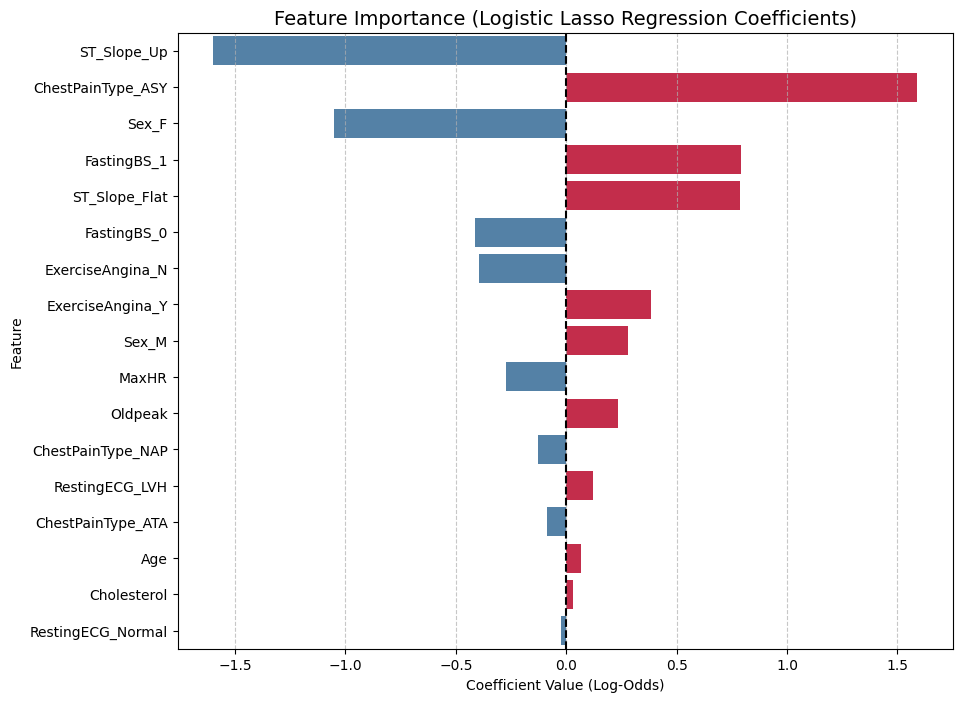

Features eliminated by L1 regularization: ['RestingBP', 'ChestPainType_TA', 'RestingECG_ST', 'ST_Slope_Down']


In [52]:
# --- Q2.4: Visualize Feature Importance ---
# Extract coefficients and flatten the array
coefficients = lasso_model.coef_[0]

# Create a DataFrame for easy sorting and plotting
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefficients
})

# Filter out features that were completely zeroed out by the Lasso penalty
feature_importance_df = feature_importance_df[feature_importance_df['Coefficient'] != 0]

# Sort by the absolute value of the coefficient to see the most impactful features at the top
feature_importance_df['Abs_Coefficient'] = feature_importance_df['Coefficient'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Abs_Coefficient', ascending=False)

# Determine colors and convert the numpy array to a standard Python list
colors = np.where(feature_importance_df['Coefficient'] > 0, 'crimson', 'steelblue').tolist()

# Plotting
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Coefficient', 
    y='Feature', 
    data=feature_importance_df, 
    hue='Feature',   
    legend=False,    
    palette=colors  
)

plt.axvline(x=0, color='black', linestyle='--')
plt.title('Feature Importance (Logistic Lasso Regression Coefficients)', fontsize=14)
plt.xlabel('Coefficient Value (Log-Odds)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Print the features that were eliminated
zeroed_features = [f for f, c in zip(all_feature_names, lasso_model.coef_[0]) if c == 0]
print(f"Features eliminated by L1 regularization: {zeroed_features}")

In [53]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, balanced_accuracy_score, classification_report

# --- Q3.1: Implement and Train the MLP ---
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32), 
    activation='relu', 
    solver='adam', 
    max_iter=1000,
    random_state=42
)

# Fit the model on the preprocessed training data
mlp_model.fit(X_train_final, y_train)

# Predict on the test set
y_pred_mlp = mlp_model.predict(X_test_final)

# Report Performance
f1_mlp = f1_score(y_test, y_pred_mlp)
bal_acc_mlp = balanced_accuracy_score(y_test, y_pred_mlp)

print(f"MLP F1-Score: {f1_mlp:.4f}")
print(f"MLP Balanced Accuracy: {bal_acc_mlp:.4f}\n")
print("MLP Classification Report:")
print(classification_report(y_test, y_pred_mlp))

MLP F1-Score: 0.8333
MLP Balanced Accuracy: 0.8130

MLP Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        82
           1       0.83      0.83      0.83       102

    accuracy                           0.82       184
   macro avg       0.81      0.81      0.81       184
weighted avg       0.82      0.82      0.82       184



100%|██████████| 4/4 [00:00<00:00, 26.16it/s]



--- SHAP Explanation for Patient Index 1 (Actual Label: 1) ---


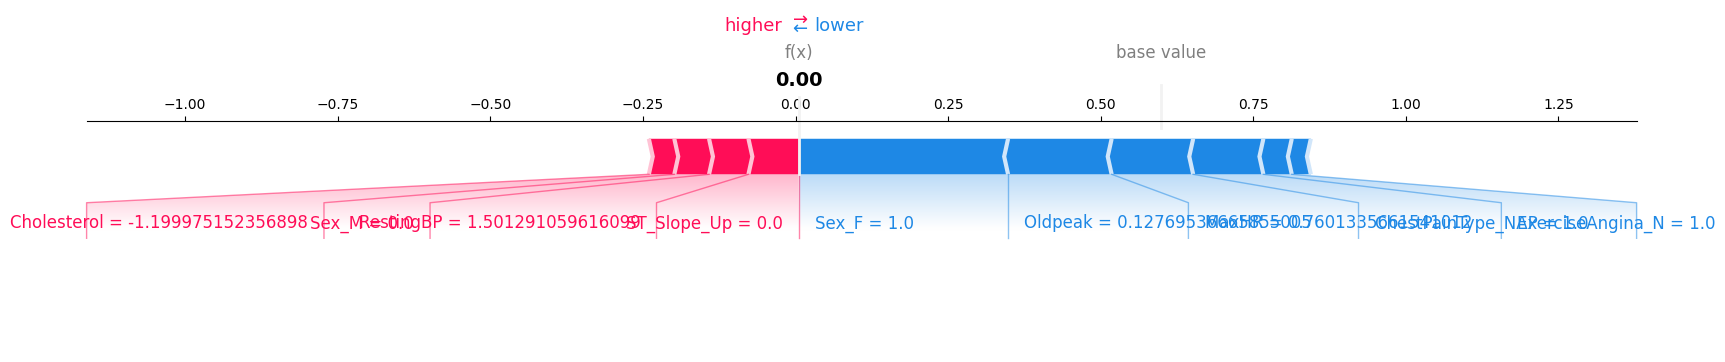


--- SHAP Explanation for Patient Index 11 (Actual Label: 1) ---


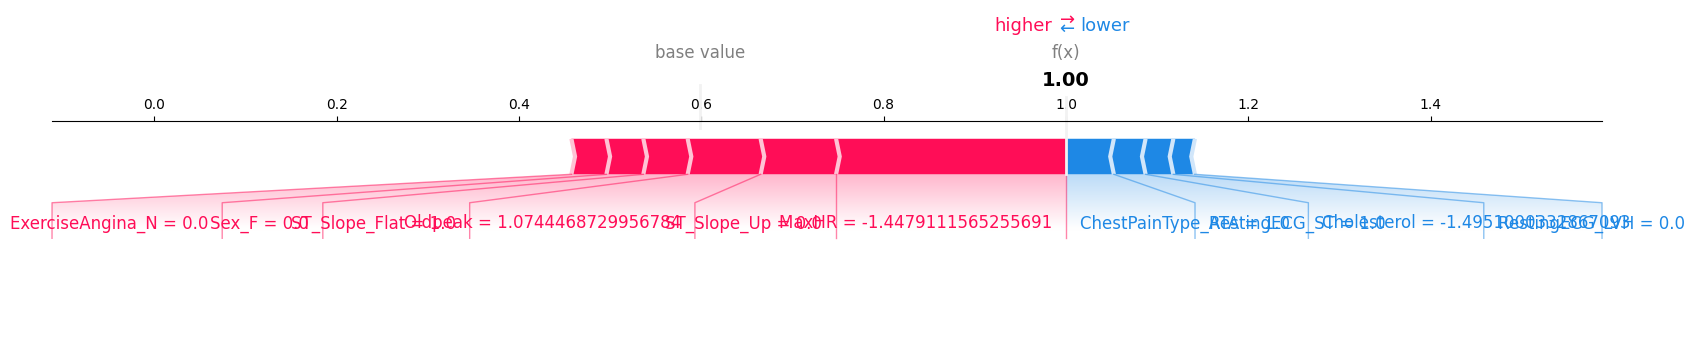


--- SHAP Explanation for Patient Index 2 (Actual Label: 0) ---


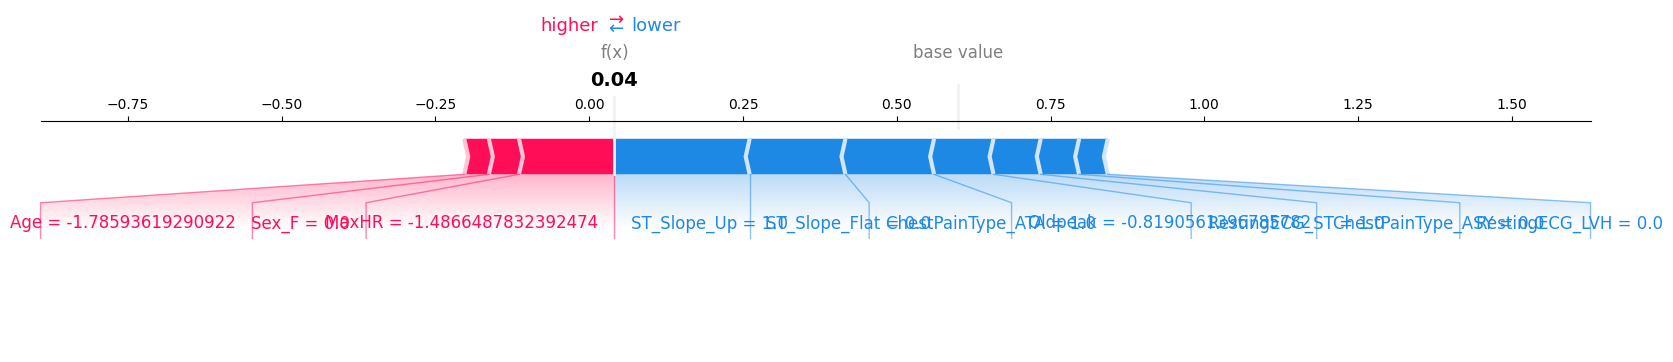


--- SHAP Explanation for Patient Index 21 (Actual Label: 0) ---


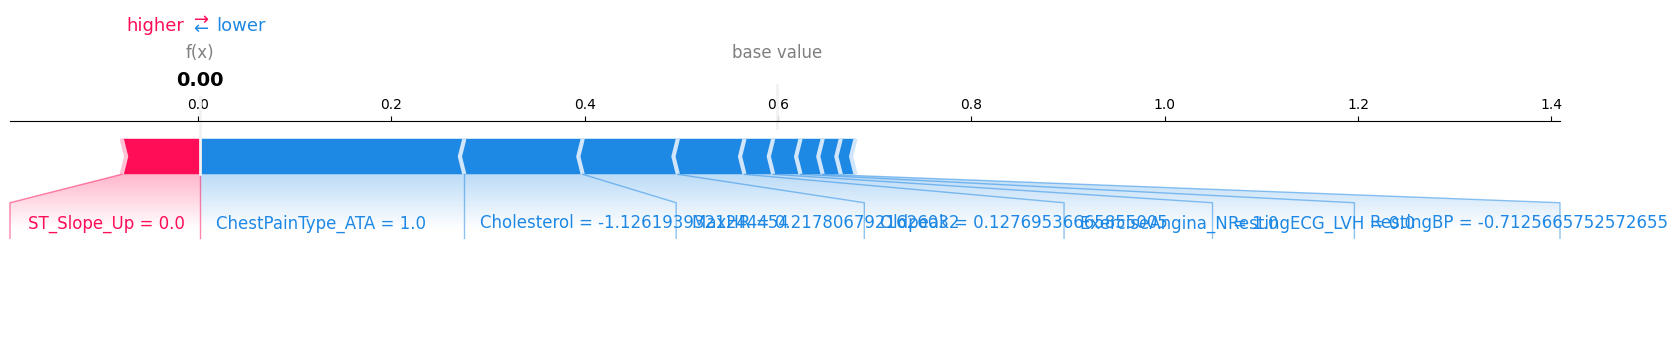

100%|██████████| 100/100 [00:03<00:00, 27.06it/s]



--- Overall Feature Importances (Summary Plot) ---


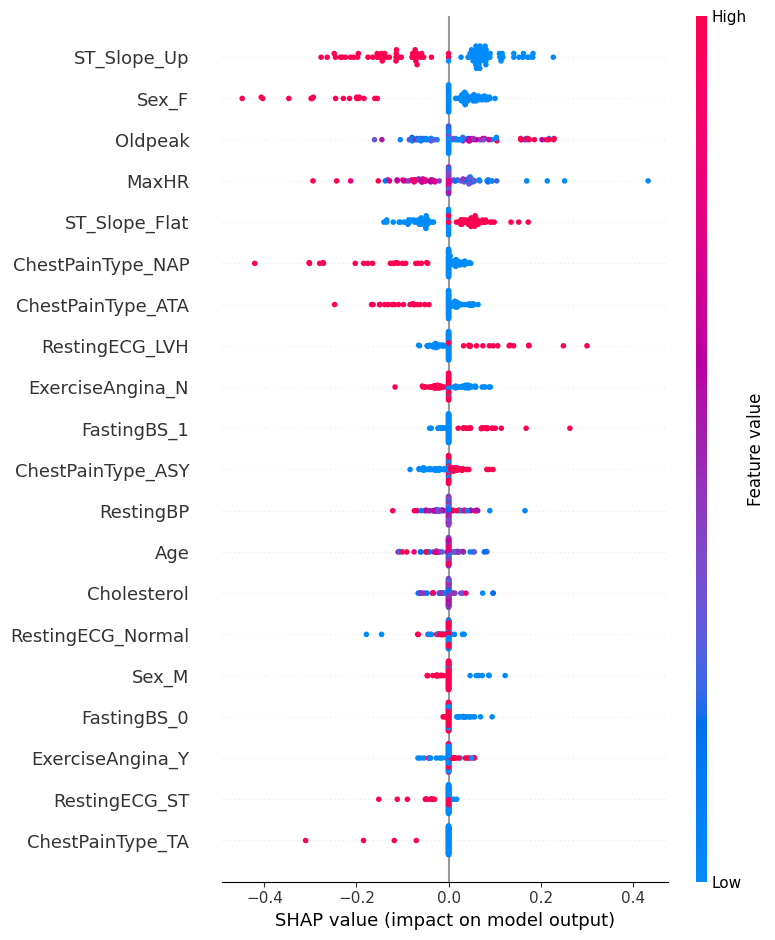

In [54]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extract the feature names from your training data
feature_cols = X_train_final.columns

# 2. Update the wrapper function to reconstruct the DataFrame
def predict_class1_proba(x):
    # 'x' comes in as a numpy array from SHAP. 
    # We turn it back into a DataFrame so the MLPClassifier gets the feature names it expects.
    x_df = pd.DataFrame(x, columns=feature_cols)
    return mlp_model.predict_proba(x_df)[:, 1]

# 3. Create a background dataset summary
background = shap.kmeans(X_train_final, 50)

# 4. Initialize the Explainer using the updated wrapper function
explainer = shap.KernelExplainer(predict_class1_proba, background)

# 5. Find specific samples in the test set
pos_indices = y_test[y_test == 1].index[:2]
neg_indices = y_test[y_test == 0].index[:2]
sample_indices = list(pos_indices) + list(neg_indices)
samples_to_explain = X_test_final.loc[sample_indices]

# 6. Calculate SHAP values
shap_values_samples = explainer.shap_values(samples_to_explain)

# Visualize Individual Predictions
shap.initjs()

for i, idx in enumerate(sample_indices):
    actual_label = y_test.loc[idx]
    print(f"\n--- SHAP Explanation for Patient Index {idx} (Actual Label: {actual_label}) ---")
    
    shap.force_plot(
        explainer.expected_value, 
        shap_values_samples[i, :], 
        samples_to_explain.iloc[i, :],
        matplotlib=True
    )
    plt.show()

# Visualize Overall Model Importances
X_test_sample = X_test_final.sample(n=min(100, len(X_test_final)), random_state=42)
shap_values_global = explainer.shap_values(X_test_sample)

print("\n--- Overall Feature Importances (Summary Plot) ---")
shap.summary_plot(shap_values_global, X_test_sample)

In [55]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score, balanced_accuracy_score, classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert Pandas DataFrames to PyTorch Tensors
X_train_t = torch.tensor(X_train_final.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1) # Reshape for BCE Loss
X_test_t = torch.tensor(X_test_final.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

# Create DataLoaders
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 2. Define the Neural Additive Model Architecture
class FeatureNN(nn.Module):
    """A small neural network assigned to a SINGLE feature."""
    def __init__(self, hidden_dim=32):
        super(FeatureNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1) # Outputs a single scalar contribution
        )

    def forward(self, x):
        return self.net(x)

class NAM(nn.Module):
    """The full Neural Additive Model."""
    def __init__(self, num_features):
        super(NAM, self).__init__()
        # Create a list of FeatureNNs, one for each feature
        self.feature_nets = nn.ModuleList([FeatureNN() for _ in range(num_features)])
        self.bias = nn.Parameter(torch.zeros(1)) # Global bias

    def forward(self, x):
        # x shape: (batch_size, num_features)
        batch_size, num_features = x.shape
        
        # Calculate the contribution of each feature
        contributions = []
        for i in range(num_features):
            # Extract the i-th feature column, reshape to (batch, 1), and pass to its network
            feature_col = x[:, i].view(-1, 1)
            contributions.append(self.feature_nets[i](feature_col))
            
        # Stack contributions: shape becomes (batch_size, num_features)
        stacked_contributions = torch.cat(contributions, dim=1)
        
        # Sum all feature contributions and add the global bias
        # Apply Sigmoid to get probability outputs between 0 and 1
        output = torch.sum(stacked_contributions, dim=1, keepdim=True) + self.bias
        return torch.sigmoid(output)

# 3. Initialize and Train the Model
num_features = X_train_t.shape[1]
nam_model = NAM(num_features)

criterion = nn.BCELoss() # Binary Cross Entropy for classification
optimizer = optim.Adam(nam_model.parameters(), lr=0.005, weight_decay=1e-4)

# Training Loop
epochs = 50
nam_model.train()
for epoch in range(epochs):
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = nam_model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()

# 4. Evaluate Performance
nam_model.eval()
with torch.no_grad():
    y_pred_probs = nam_model(X_test_t)
    y_pred_nam = (y_pred_probs >= 0.5).float().numpy()

f1_nam = f1_score(y_test, y_pred_nam)
bal_acc_nam = balanced_accuracy_score(y_test, y_pred_nam)

print(f"NAM F1-Score: {f1_nam:.4f}")
print(f"NAM Balanced Accuracy: {bal_acc_nam:.4f}\n")
print("NAM Classification Report:")
print(classification_report(y_test, y_pred_nam))

NAM F1-Score: 0.8744
NAM Balanced Accuracy: 0.8655

NAM Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85        82
           1       0.90      0.85      0.87       102

    accuracy                           0.86       184
   macro avg       0.86      0.87      0.86       184
weighted avg       0.87      0.86      0.86       184



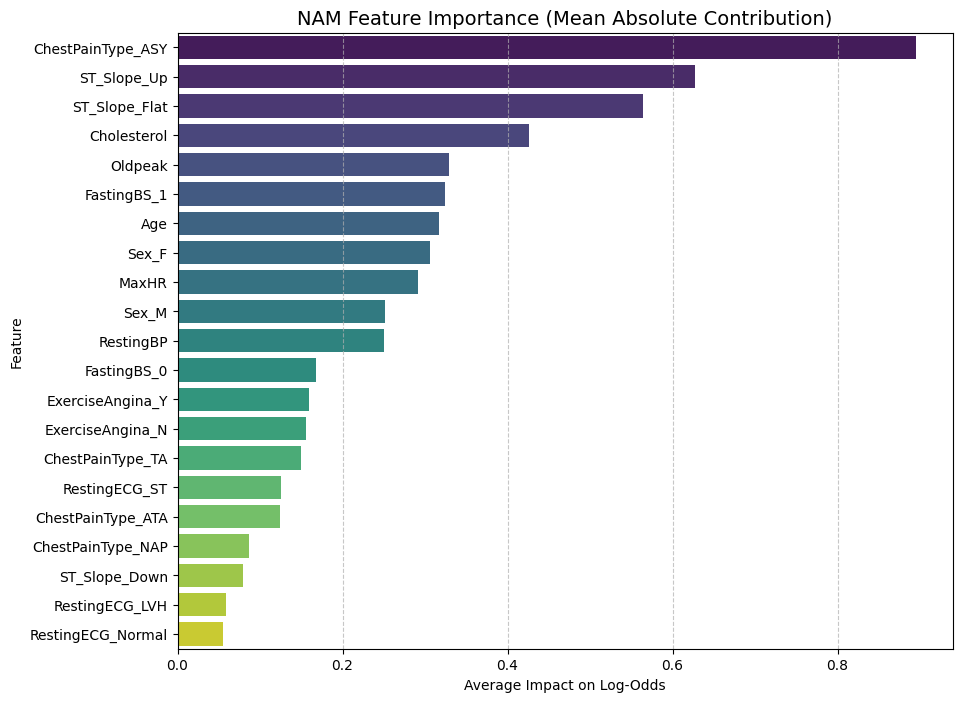

In [56]:
# --- Q4.2: Visualize NAM Feature Importances ---

feature_importances = []
nam_model.eval()
with torch.no_grad():
    for i in range(num_features):
        # Extract the i-th feature from the test set
        feature_col = X_test_t[:, i].view(-1, 1)
        
        # Pass it through its dedicated sub-network
        contributions = nam_model.feature_nets[i](feature_col)
        
        # The importance is the Mean Absolute Contribution
        mean_abs_contribution = torch.mean(torch.abs(contributions)).item()
        feature_importances.append(mean_abs_contribution)

# Create DataFrame for plotting
nam_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
})

# Sort for better visualization
nam_importance_df = nam_importance_df.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=nam_importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('NAM Feature Importance (Mean Absolute Contribution)', fontsize=14)
plt.xlabel('Average Impact on Log-Odds')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()